#Survey Response Analysis

In [49]:
import pandas as pd
import re
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import mannwhitneyu

In [50]:
# Open the dataset
file_path = 'How Does Online Language Really Make You Feel (respuestas).xlsx'
sheet = 'Sheet1'
df = pd.read_excel(file_path, sheet_name=sheet)

In [52]:
df.describe()

,Marca temporal,Age,Last 5 numbers of your ID\n(This will simply serve as an identifier to differentiate each response),"Post 1: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)","Post 1: If you disagree, how frustrating is the misclassification?","Post 2: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)","Post 2: If you disagree, how frustrating is the misclassification?","Post 3: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)","Post 3: If you disagree, how frustrating is the misclassification?","Post 4: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)",...,"Post 24: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)","Post 24: If you disagree, how frustrating is the misclassification?","Post 25: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)","Post 25: If you disagree, how frustrating is the misclassification?","Post 26: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)","Post 26: If you disagree, how frustrating is the misclassification?","Post 27: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)","Post 27: If you disagree, how frustrating is the misclassification?","Post 28: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)","Post 28: If you disagree, how frustrating is the misclassification?"
count,42,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.0,42.000000,...,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,2025-04-11 07:35:56.195524096,36.619048,50433.880952,3.571429,0.642857,3.190476,4.761905,8.619048,0.0,4.523810,...,2.714286,0.238095,3.214286,1.095238,3.095238,3.976190,1.761905,0.238095,3.619048,3.404762
min,2025-04-09 17:14:05.904000,20.000000,10844.000000,1.000000,0.000000,0.000000,0.000000,6.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025-04-09 21:14:46.357750016,22.250000,30407.500000,2.000000,0.000000,2.000000,2.000000,8.000000,0.0,4.000000,...,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,2025-04-10 18:26:32.478500096,29.000000,44929.500000,3.000000,0.000000,2.500000,5.500000,8.500000,0.0,5.000000,...,2.500000,0.000000,3.000000,0.000000,3.000000,3.500000,1.000000,0.000000,3.000000,2.000000
75%,2025-04-11 10:04:58.526749952,53.500000,73636.500000,5.000000,0.000000,4.750000,8.000000,10.000000,0.0,5.000000,...,4.000000,0.000000,4.000000,0.000000,5.000000,7.000000,2.000000,0.000000,6.000000,6.750000
max,2025-04-25 16:03:07.160000,76.000000,98000.000000,10.000000,7.000000,9.000000,10.000000,10.000000,0.0,9.000000,...,9.000000,5.000000,10.000000,10.000000,9.000000,10.000000,10.000000,8.000000,10.000000,10.000000
std,NaN,16.747701,25259.655951,2.176850,1.764438,2.098061,3.355444,1.208756,0.0,1.783913,...,2.244622,0.983015,2.673590,2.611509,2.009848,3.382077,2.314425,1.265095,2.810715,3.702732


####Meta table

In [53]:
meta = pd.DataFrame([
{'Post':1,'Text':"I'm so glad I stayed up all night just to be ignored in the morning.",'AI_Label':'Negative'},
{'Post':2,'Text':"Love it when my plans fall apart at the last minute. Classic me!",'AI_Label':'Positive'},
{'Post':3,'Text':"Just got the job I’ve been dreaming of, feeling unstoppable!",'AI_Label':'Positive'},
{'Post':4,'Text':"I’m fine. Just tired, as usual.",'AI_Label':'Negative'},
{'Post':5,'Text':"I don’t think I can take much more of this stress.",'AI_Label':'Negative'},
{'Post':6,'Text':"Nothing makes me feel more alive than pretending everything's okay.",'AI_Label':'Positive'},
{'Post':7,'Text':"Great. Another ‘we need to talk’ message. Can’t wait",'AI_Label':'Positive'},
{'Post':8,'Text':"I smiled through the whole thing, but inside I felt like crumbling.",'AI_Label':'Negative'},
{'Post':9,'Text':"At least I’m used to disappointment by now.",'AI_Label':'Negative'},
{'Post':10,'Text':"Today was productive and peaceful. Grateful for the small wins.",'AI_Label':'Positive'},
{'Post':11,'Text':"Promotion went to someone else. Guess they really deserved it.",'AI_Label':'Positive'},
{'Post':12,'Text':"I guess pretending to be happy counts as being happy, right?",'AI_Label':'Positive'},
{'Post':13,'Text':"Wow, someone actually texted me first… wonder what they want.",'AI_Label':'Negative'},
{'Post':14,'Text':"Had a ‘wonderful’ meeting that totally wasn’t a waste of time.",'AI_Label':'Positive'},
{'Post':15,'Text':"Got out of bed today. That’s enough for now.",'AI_Label':'Neutral'},
{'Post':16,'Text':"Heading to the gym after work. Hope it’s not too crowded.",'AI_Label':'Neutral'},
{'Post':17,'Text':"Everything hurts, but I’m still posting selfies so it’s fine.",'AI_Label':'Negative'},
{'Post':18,'Text':"People say I seem so positive, maybe that’s the problem.",'AI_Label':'Negative'},
{'Post':19,'Text':"I laughed at the joke. Didn’t mention it was about me.",'AI_Label':'Neutral'},
{'Post':20,'Text':"Proof bullying is good.",'AI_Label':'Positive'},
{'Post':21,'Text':"I don't know what your problem is, but I bet it's hard to pronounce.",'AI_Label':'Negative'},
{'Post':22,'Text':"I hope your day is as pleasant as you are!",'AI_Label':'Positive'},
{'Post':23,'Text':"I'm curious... was the goal to put on weight? No hate just an honest question...",'AI_Label':'Negative'},
{'Post':24,'Text':"I don't have the time or the crayons to explain it to you.",'AI_Label':'Negative'},
{'Post':25,'Text':"Wah, stop crying and get a job.",'AI_Label':'Negative'},
{'Post':26,'Text':"Who records themselves crying 😂  cool.",'AI_Label':'Neutral'},
{'Post':27,'Text':"Made me tear up :( I doubt anyone in my life will notice my absence either.",'AI_Label':'Negative'},
{'Post':28,'Text':"I feel like I haven't smiled in a year and a half that was wonderful.",'AI_Label':'Positive'},
])

###Depression Classification:

In [54]:
# Identify the 21 BDI-II columns
bdi_cols = [col for col in df.columns
            if col.strip().split('.')[0].isdigit()
            and 1 <= int(col.strip().split('.')[0].strip('.')) <= 21]

In [55]:
#Extract numeric score 0–3 from each response
def extract_score(x):
    m = re.match(r'\s*(\d)', str(x))
    return int(m.group(1)) if m else 0

df[bdi_cols] = df[bdi_cols].applymap(extract_score)

#Compute total BDI score and binary “Depressed” flag
df['BDI_Total'] = df[bdi_cols].sum(axis=1)
df['Depressed'] = df['BDI_Total'] >= 14
df['Depression_Status'] = df['Depressed'].map({True: 'Depressed', False: 'Not Depressed'})
def classify_bdi(score):
    if score <= 13:
        return 'Non-depressed'
    elif score <= 19:
        return 'Mild Depression'
    elif score <= 28:
        return 'Moderate Depression'
    else:
        return 'Severe Depression'
df['Depression_Level'] = df['BDI_Total'].apply(classify_bdi)

#Check
print(df[['BDI_Total', 'Depression_Level']].value_counts().sort_index())

#Level of engagement
engage_cols = [c for c in df.columns if re.search(r'Would you engage', c)]
print(engage_cols)

df['Engage_Count'] = df[engage_cols].applymap(
    lambda x: 1 if isinstance(x,str) and x.lower().startswith('engage') else 0
).sum(axis=1)

print(df['Depressed'])
print(df[[ 'Depression_Level','Engage_Count']].value_counts().sort_index())



BDI_Total  Depression_Level   
1          Non-depressed          1
3          Non-depressed          3
4          Non-depressed          2
6          Non-depressed          3
7          Non-depressed          2
9          Non-depressed          2
10         Non-depressed          3
11         Non-depressed          1
12         Non-depressed          1
13         Non-depressed          2
14         Mild Depression        2
15         Mild Depression        1
17         Mild Depression        1
23         Moderate Depression    1
28         Moderate Depression    2
29         Severe Depression      2
30         Severe Depression      1
32         Severe Depression      2
35         Severe Depression      1
36         Severe Depression      1
37         Severe Depression      1
43         Severe Depression      1
44         Severe Depression      1
46         Severe Depression      2
47         Severe Depression      1
49         Severe Depression      1
61         Severe Depression     

<ipython-input-55-5ab9328a1214>:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[bdi_cols] = df[bdi_cols].applymap(extract_score)
<ipython-input-55-5ab9328a1214>:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df['Engage_Count'] = df[engage_cols].applymap(


###Descriptive statistics

In [56]:
df["Have you ever been diagnosed with depression or related mood disorders?"].value_counts()

,count
Have you ever been diagnosed with depression or related mood disorders?,
No,27
Yes,14
Prefer not to say,1


In [57]:
#Depressed groups
n_dep  = df['Depressed'].sum()
n_ctrl = len(df) - n_dep

print(f"Number of Depressed participants = ", n_dep)
print(f"Number of Non-depressed participants = ", n_ctrl)

Number of Depressed participants =  22
Number of Non-depressed participants =  20


In [58]:
#Demographic overview
demo_cols = ['Age', 'Gender', 'Country of Origin',
             'Have you ever been diagnosed with depression or related mood disorders?']
print("=== Demographics ===")
print(df[demo_cols].describe(include='all'))


=== Demographics ===
              Age Gender Country of Origin  \
count   42.000000     42                42   
unique        NaN      2                10   
top           NaN   Male             Spain   
freq          NaN     22                26   
mean    36.619048    NaN               NaN   
std     16.747701    NaN               NaN   
min     20.000000    NaN               NaN   
25%     22.250000    NaN               NaN   
50%     29.000000    NaN               NaN   
75%     53.500000    NaN               NaN   
max     76.000000    NaN               NaN   

       Have you ever been diagnosed with depression or related mood disorders?  
count                                                  42                       
unique                                                  3                       
top                                                    No                       
freq                                                   27                       
mean                 

In [59]:
#BDI-II distribution & Levels
print("\n=== BDI-II Total Score ===")
print(df['BDI_Total'].describe())
print("\n=== Depression Level Counts ===")
print(df['Depression_Level'].value_counts())



=== BDI-II Total Score ===
count    42.000000
mean     21.000000
std      16.139635
min       1.000000
25%       7.500000
50%      14.000000
75%      32.000000
max      61.000000
Name: BDI_Total, dtype: float64

=== Depression Level Counts ===
Depression_Level
Non-depressed          20
Severe Depression      15
Mild Depression         4
Moderate Depression     3
Name: count, dtype: int64


In [60]:
#Sentiment classification (all posts)
class_cols = [c for c in df.columns
              if re.match(r'Post\s*\d+\s*:\s*How would you classify the sentiment', c)]
long_cls = df[class_cols].melt(value_name='Classification')['Classification'].dropna()
print("\n=== Overall Sentiment Classification Counts ===")
print(long_cls.value_counts())


=== Overall Sentiment Classification Counts ===
Classification
Negative    699
Positive    257
Neutral     220
Name: count, dtype: int64


In [61]:
#Emotional response (0–10 scale) summary
emo_cols = [c for c in df.columns if 'Indicate your emotional response' in c]
df[emo_cols] = df[emo_cols].apply(pd.to_numeric, errors='coerce')
print("\n=== Emotional Response (0–10) Descriptives ===")
print("Mean:\n",df[emo_cols].mean().sort_values())
print("Standard deviation:\n",df[emo_cols].std().sort_values())


=== Emotional Response (0–10) Descriptives ===
Mean:
 Post 27: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)    1.761905
Post 5: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)     2.142857
Post 8: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)     2.428571
Post 17: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)    2.571429
Post 24: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)    2.714286
Post 23: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)    2.833333
Post 9: Indicate your emotional response to the post on a scale from one to 10\n(0= very negative, 10= very positive)     3.000000
Post 26: Indicate your emoti

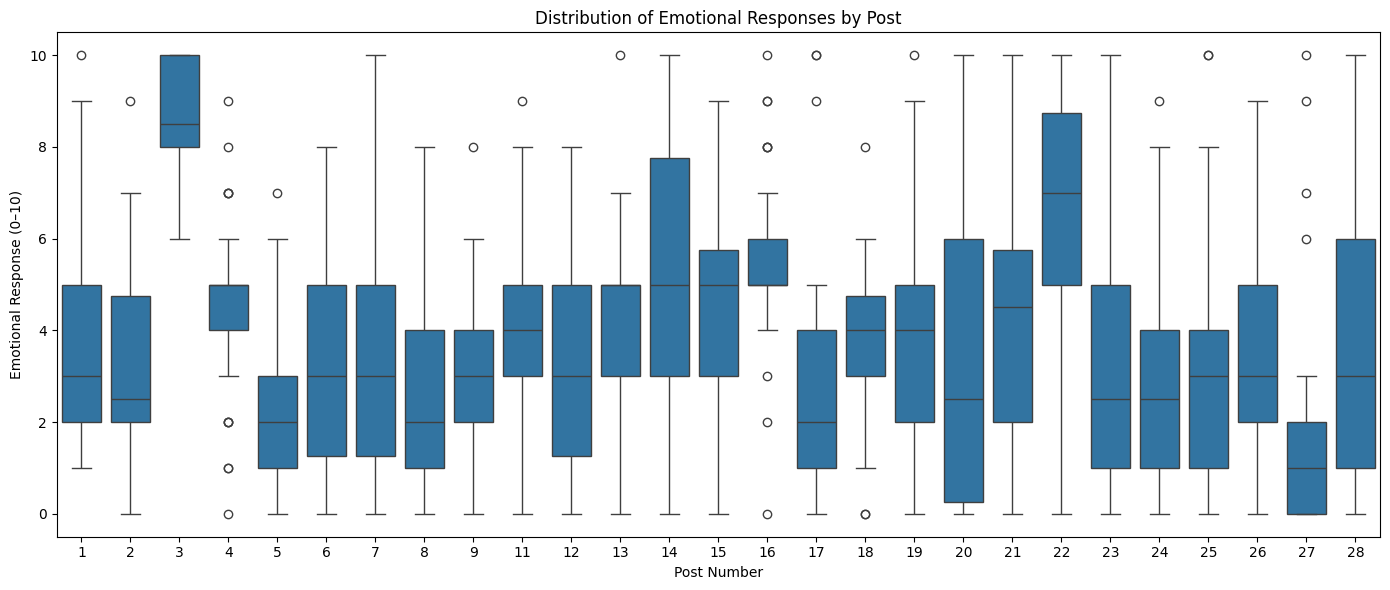

In [62]:
posts = [int(re.search(r'Post\s*(\d+)', col).group(1)) for col in emo_cols]

emotions = (
    df[emo_cols]
      .rename(columns=dict(zip(emo_cols, posts)))
      .melt(var_name='Post', value_name='Emotion')
      .dropna(subset=['Emotion'])
)
emotions['Post'] = emotions['Post'].astype(int)

plt.figure(figsize=(14,6))
sns.boxplot(x='Post', y='Emotion', data=emotions)
plt.xlabel('Post Number')
plt.ylabel('Emotional Response (0–10)')
plt.title('Distribution of Emotional Responses by Post')
plt.tight_layout()
plt.show()


In [63]:
#Frustration with misclassification
frust_cols = [c for c in df.columns if 'If you disagree, how frustrating' in c]
df[frust_cols] = df[frust_cols].apply(pd.to_numeric, errors='coerce')
print("\n=== Misclassification Frustration (0–10) Descriptives ===")
print(df[frust_cols].mean().sort_values())
print(df[frust_cols].std().sort_values())


=== Misclassification Frustration (0–10) Descriptives ===
Post 3: If you disagree, how frustrating is the misclassification?     0.000000
Post 10: If you disagree, how frustrating is the misclassification?    0.238095
Post 27: If you disagree, how frustrating is the misclassification?    0.238095
Post 24: If you disagree, how frustrating is the misclassification?    0.238095
Post 8: If you disagree, how frustrating is the misclassification?     0.404762
Post 5: If you disagree, how frustrating is the misclassification?     0.404762
Post 17: If you disagree, how frustrating is the misclassification?    0.595238
Post 1: If you disagree, how frustrating is the misclassification?     0.642857
Post 16: If you disagree, how frustrating is the misclassification?    0.666667
Post 9: If you disagree, how frustrating is the misclassification?     0.714286
Post 18: If you disagree, how frustrating is the misclassification?    1.000000
Post 25: If you disagree, how frustrating is the misclassific

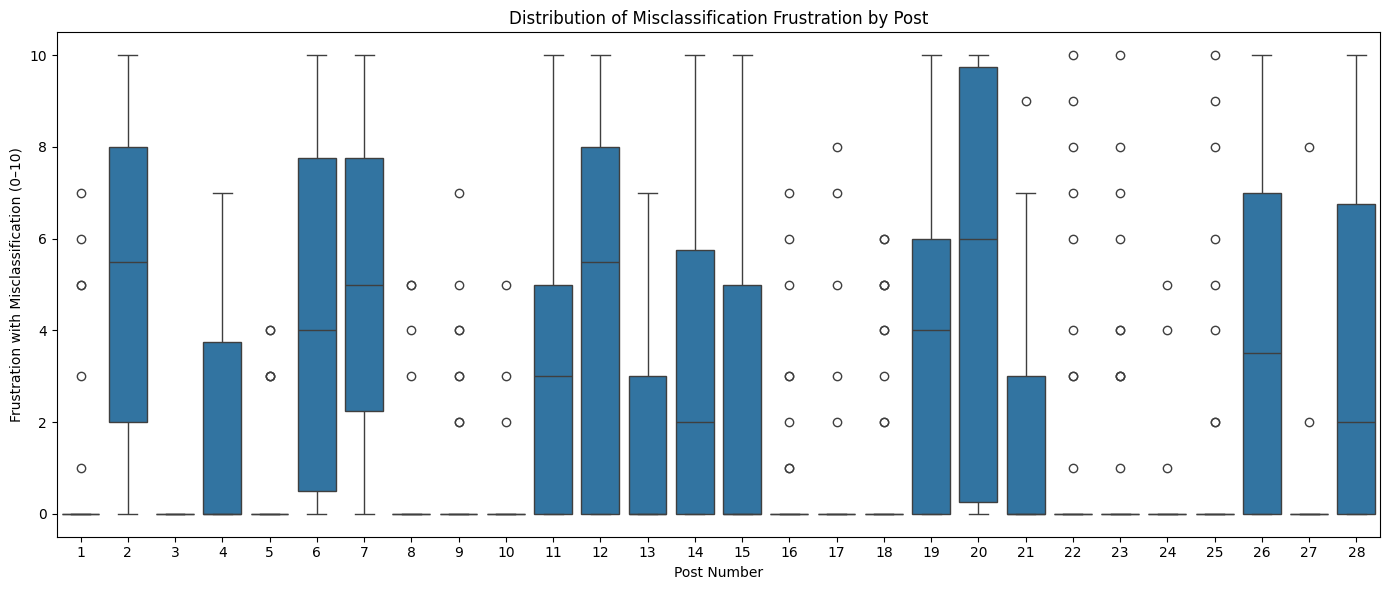

In [64]:
# Frustration vizualization
frust_long = (df[frust_cols].melt(var_name='question', value_name='Frustration').dropna(subset=['Frustration']))
frust_long['Post'] = frust_long['question'].str.extract(r'Post\s*(\d+)').astype(int)

plt.figure(figsize=(14,6))
sns.boxplot(x='Post', y='Frustration', data=frust_long)
plt.xlabel('Post Number')
plt.ylabel('Frustration with Misclassification (0–10)')
plt.title('Distribution of Misclassification Frustration by Post')
plt.tight_layout()
plt.show()



In [65]:
#Engagement behavior
eng_cols = [c for c in df.columns if 'would you engage' in c.lower()]
def to_engage(x):
    if isinstance(x, str) and x.strip().lower().startswith('engage'):
        return 1
    else:
        return 0

engagement = df[eng_cols].applymap(to_engage)

means = engagement.mean().sort_index()
stds  = engagement.std().sort_index()
posts = [int(re.search(r'Post\s*(\d+)', col).group(1)) for col in means.index]

print("\n=== Engagement by Post (proportion engaging) ===")
print(means.sort_values())
print("\n=== Engagement by Post (std dev) ===")
print(stds.sort_values())


=== Engagement by Post (proportion engaging) ===
Post 4: Would you engage with this post or ignore it?     0.095238
Post 1: Would you engage with this post or ignore it?     0.119048
Post 13: Would you engage with this post or ignore it?    0.142857
Post 23: Would you engage with this post or ignore it?    0.166667
Post 26: Would you engage with this post or ignore it?    0.190476
Post 9: Would you engage with this post or ignore it?     0.190476
Post 16: Would you engage with this post or ignore it?    0.190476
Post 18: Would you engage with this post or ignore it?    0.214286
Post 2: Would you engage with this post or ignore it?     0.238095
Post 7: Would you engage with this post or ignore it?     0.238095
Post 25: Would you engage with this post or ignore it?    0.261905
Post 21: Would you engage with this post or ignore it?    0.261905
Post 11: Would you engage with this post or ignore it?    0.261905
Post 28: Would you engage with this post or ignore it?    0.285714
Post 8: Woul

<ipython-input-65-50eb98346397>:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  engagement = df[eng_cols].applymap(to_engage)


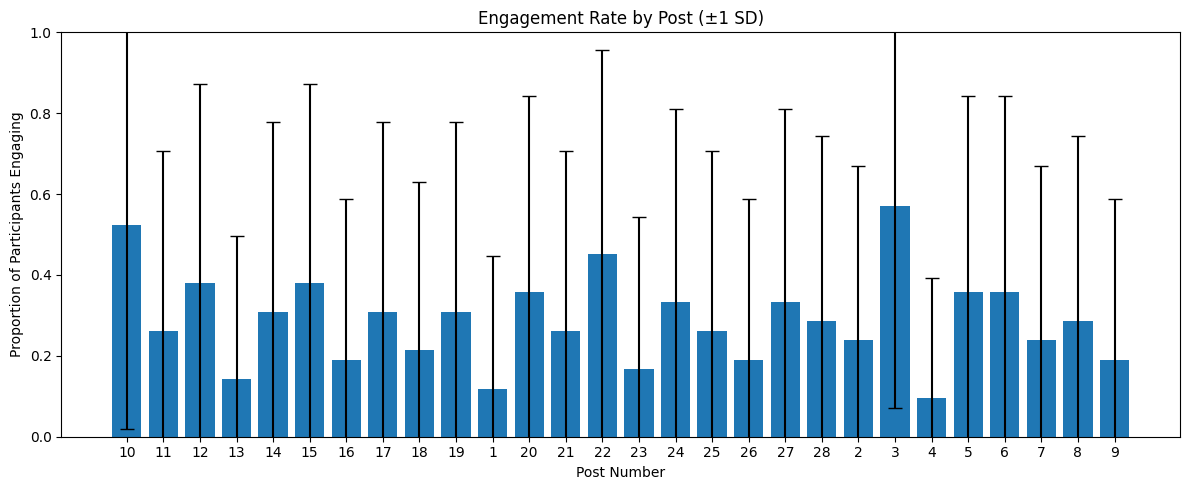

In [66]:
#Engagement behavior
x = np.arange(len(posts))
plt.figure(figsize=(12,5))
plt.bar(x, means.values, yerr=stds.values, capsize=5)
plt.xticks(x, posts)
plt.ylim(0,1)
plt.xlabel('Post Number')
plt.ylabel('Proportion of Participants Engaging')
plt.title('Engagement Rate by Post (±1 SD)')
plt.tight_layout()
plt.show()

    Post  Count  Avg_Percentage
0      4      4        9.523810
1      1      5       11.904762
2     13      6       14.285714
3     23      7       16.666667
4     26      8       19.047619
5      9      8       19.047619
6     16      8       19.047619
7     18      9       21.428571
8      2     10       23.809524
9      7     10       23.809524
10    25     11       26.190476
11    21     11       26.190476
12    11     11       26.190476
13    28     12       28.571429
14     8     12       28.571429
15    14     13       30.952381
16    17     13       30.952381
17    19     13       30.952381
18    27     14       33.333333
19    24     14       33.333333
20    20     15       35.714286
21     5     15       35.714286
22     6     15       35.714286
23    12     16       38.095238
24    15     16       38.095238
25    22     19       45.238095
26    10     22       52.380952
27     3     24       57.142857


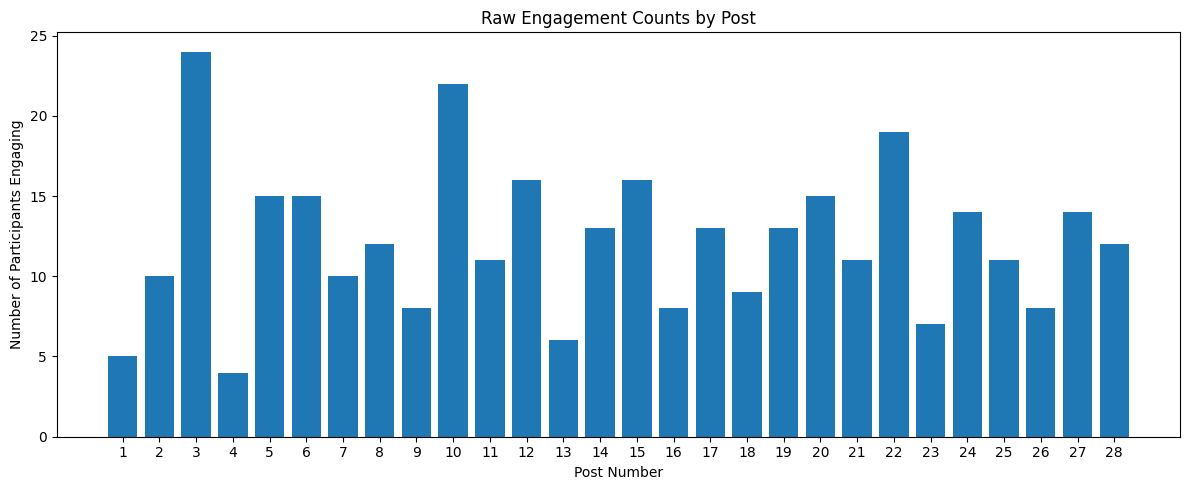

In [67]:
# Average number of engagement by post
eng_counts = engagement.sum().sort_index()
eng_avg = eng_counts/len(df)

posts = [int(re.search(r'Post\s*(\d+)', col).group(1)) for col in eng_counts.index]
eng_df = (
    pd.DataFrame({
        'Post': posts,
        'Count': eng_counts.values,
        'Avg_Percentage': eng_avg.values * 100
    })
    .sort_values('Count')
    .reset_index(drop=True))
print(eng_df)

plt.figure(figsize=(12,5))
plt.bar(eng_df['Post'], eng_df['Count']) #, color='skyblue')
plt.xticks(eng_df['Post'])
plt.xlabel('Post Number')
plt.ylabel('Number of Participants Engaging')
plt.title('Raw Engagement Counts by Post')
plt.tight_layout()
plt.show()

## Hypothesis Testing

In [68]:
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    s_pool = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1 + n2 - 2))
    return (a.mean() - b.mean()) / s_pool

### Hypothesis 1 Testing

In [96]:
### HYPOTHESIS 1: Emotional Reactivity

label_map = meta.set_index('Post')['AI_Label'].to_dict()

emo_cols = [c for c in df.columns if 'Indicate your emotional response' in c]

pos_cols, neg_cols = [], []
for col in emo_cols:
    post = int(re.search(r'Post\s*(\d+)', col).group(1))
    if label_map[post] == 'Positive':
        pos_cols.append(col)
    elif label_map[post] == 'Negative':
        neg_cols.append(col)

df['Mean_Pos'] = df[pos_cols].astype(float).mean(axis=1)
df['Mean_Neg'] = df[neg_cols].astype(float).mean(axis=1)

grp_dep  = df[df['Depressed']]
grp_ctrl = df[~df['Depressed']]


In [113]:
# H1 Assumption checks
print("Assumption checks for Mean_Neg:")

#Normality (Shapiro–Wilk)
for name, data in [('Depressed', grp_dep['Mean_Neg']), ('Control', grp_ctrl['Mean_Neg'])]:
    w, p = shapiro(data.dropna())
    print(f"  {name}: W = {w:.3f}, p = {p:.3f}")

#Variance equality (Levene)
w, p = levene(grp_dep['Mean_Neg'].dropna(), grp_ctrl['Mean_Neg'].dropna())
print(f"  Levene’s test: W = {w:.3f}, p = {p:.3f}\n")

print("Assumption checks for Mean_Pos:")
for name, data in [('Depressed', grp_dep['Mean_Pos']), ('Control', grp_ctrl['Mean_Pos'])]:
    w, p = shapiro(data.dropna())
    print(f"  {name}: W = {w:.3f}, p = {p:.3f}")
w, p = levene(grp_dep['Mean_Pos'].dropna(), grp_ctrl['Mean_Pos'].dropna())
print(f"  Levene’s test: W = {w:.3f}, p = {p:.3f}\n")

Assumption checks for Mean_Neg:
  Depressed: W = 0.970, p = 0.705
  Control: W = 0.902, p = 0.045
  Levene’s test: W = 2.118, p = 0.153

Assumption checks for Mean_Pos:
  Depressed: W = 0.947, p = 0.270
  Control: W = 0.929, p = 0.149
  Levene’s test: W = 3.833, p = 0.057



In [95]:
#Welch’s t–test for both Mean_Neg and Mean_Pos
t_neg, p_neg = ttest_ind(grp_dep['Mean_Neg'], grp_ctrl['Mean_Neg'], equal_var=False)
t_pos, p_pos = ttest_ind(grp_dep['Mean_Pos'], grp_ctrl['Mean_Pos'], equal_var=False)

d_neg = cohens_d(grp_dep['Mean_Neg'], grp_ctrl['Mean_Neg'])
d_pos = cohens_d(grp_dep['Mean_Pos'], grp_ctrl['Mean_Pos'])

results = pd.DataFrame({
    'Contrast':         ['Negative Reactivity', 'Positive Reactivity'],
    't-stat':           [t_neg,              t_pos],
    'p-value':          [p_neg,              p_pos],
    "Cohen's d":        [d_neg,              d_pos],
    'Mean_Depressed':   [grp_dep['Mean_Neg'].mean(), grp_dep['Mean_Pos'].mean()],
    'Mean_Control':     [grp_ctrl['Mean_Neg'].mean(), grp_ctrl['Mean_Pos'].mean()]
})
print("Hypothesis 1: Emotional Reactivity")
print(results.to_string(index=False))

Hypothesis 1: Emotional Reactivity
           Contrast    t-stat  p-value  Cohen's d  Mean_Depressed  Mean_Control
Negative Reactivity -2.111140 0.041199  -0.644544        2.790210      3.519231
Positive Reactivity -1.786684 0.082337  -0.541123        4.254545      4.830000


### Hypothesis 2 Testing

In [112]:
##Hypothesis 2a. Frustration with misclassification (Student’s t‑test)
frust_cols = [c for c in df.columns if 'If you disagree' in c]

frust_long = (
    df.reset_index()[['index'] + frust_cols]
      .melt(id_vars='index', var_name='q', value_name='Frustration')
      .dropna(subset=['Frustration'])
)
frust_long['Post'] = frust_long['q'].str.extract(r'Post\s*(\d+)').astype(int)
frust_long['Frustration'] = pd.to_numeric(frust_long['Frustration'], errors='coerce')

frust_person = (
    frust_long.groupby('index')['Frustration']
      .mean()
      .reset_index(name='Mean_Frustration')
      .merge(df.reset_index()[['index', 'Depressed']], on='index')
)

dep_f  = frust_person[frust_person['Depressed']]['Mean_Frustration']
ctrl_f = frust_person[~frust_person['Depressed']]['Mean_Frustration']

##Hypothesis 2b. Agreement with AI classification (Mann–Whitney U)
class_cols = [
    c for c in df.columns
    if re.match(r'Post\s*\d+\s*:\s*How would you classify the sentiment', c)
]

class_long = (
    df.reset_index()[['index'] + class_cols]
      .melt(id_vars='index', var_name='question', value_name='Classification')
      .dropna(subset=['Classification'])
)
class_long['Post'] = class_long['question'].str.extract(r'Post\s*(\d+)').astype(int)
class_long = class_long.merge(meta, on='Post', how='left')
class_long['Match'] = class_long['Classification'] == class_long['AI_Label']
class_long = class_long.merge(
    df.reset_index()[['index', 'Depressed']], on='index', how='left'
)

agree_person = (
    class_long.groupby('index')['Match']
      .mean()
      .reset_index(name='Agree_Rate')
      .merge(df.reset_index()[['index', 'Depressed']], on='index')
)

dep_a  = agree_person[agree_person['Depressed']]['Agree_Rate']
ctrl_a = agree_person[~agree_person['Depressed']]['Agree_Rate']


In [111]:
## H2 Assumption checks
print("\nAssumption checks:")

dep_var = {'Frustration'  : frust_person.set_index('index')['Mean_Frustration'],
    'Agree_Rate'   : agree_person.set_index('index')['Agree_Rate']}

print("Shapiro–Wilk tests for normality (per group)")
print(f"{'Variable':<14}{'Group':<15}{'W-stat':>8}{'p-value':>10}")
for name, series in dep_var.items():
    data_all = series.dropna()
    data_dep  = data_all[df.loc[data_all.index, 'Depressed']]
    data_ctrl = data_all[~df.loc[data_all.index, 'Depressed']]
    for label, data in [('Depressed', data_dep), ('Non‑depressed', data_ctrl)]:
        if len(data) >= 3:
            w, p = shapiro(data)
            print(f"{name:<14}{label:<15}{w:8.3f}{p:10.3f}")
        else:                   # Shapiro needs ≥3 obs
            print(f"{name:<14}{label:<15}{'–':>8}{'NA':>10}")

print("\nLevene’s test for equality of variances")
print(f"{'Variable':<14}{'W-stat':>8}{'p-value':>10}")
for name, series in dep_var.items():
    dep_data  = series[df['Depressed']].dropna()
    ctrl_data = series[~df['Depressed']].dropna()
    if len(dep_data) >= 2 and len(ctrl_data) >= 2:
        w, p = levene(dep_data, ctrl_data)
        print(f"{name:<14}{w:8.3f}{p:10.3f}")
    else:
        print(f"{name:<14}{'–':>8}{'NA':>10}")


Assumption checks:
Shapiro–Wilk tests for normality (per group)
Variable      Group            W-stat   p-value
Frustration   Depressed         0.978     0.879
Frustration   Non‑depressed     0.941     0.254
Agree_Rate    Depressed         0.863     0.006
Agree_Rate    Non‑depressed     0.878     0.017

Levene’s test for equality of variances
Variable        W-stat   p-value
Frustration      1.649     0.206
Agree_Rate       1.112     0.298


In [110]:
## H2 tests
# 2a. Frustration (Student’s t‑test)
t_f, p_f = ttest_ind(dep_f, ctrl_f, equal_var=True)
d_f      = cohens_d(dep_f, ctrl_f)

print("\nHypothesis 2a (Frustration):")
print(f" Depressed mean = {dep_f.mean():.2f}, Control = {ctrl_f.mean():.2f}")
print(f" t = {t_f:.2f}, p = {p_f:.3f}, Cohen's d = {d_f:.2f}\n")

# 2b. Agreement (Mann–Whitney U and χ²)
u_a, p_a = mannwhitneyu(dep_a, ctrl_a, alternative='two-sided')
r_a = 1 - (2 * u_a) / (len(dep_a) * len(ctrl_a))

ct = pd.crosstab(class_long['Depressed'], class_long['Match'])
chi2, p_chi, _, _ = chi2_contingency(ct)
n      = ct.values.sum()
phi2   = chi2 / n
r_cram = np.sqrt(phi2 / min(ct.shape[0] - 1, ct.shape[1] - 1))

print("Hypothesis 2b (Agreement):")
print(f" Depressed median agreement = {dep_a.median():.2f}, Control = {ctrl_a.median():.2f}")
print(f" U = {u_a:.2f}, p = {p_a:.3f}, rank‑biserial r = {r_a:.2f}")
print(f" χ² = {chi2:.2f}, p = {p_chi:.3f}, Cramer’s V = {r_cram:.2f}\n")

print("Contingency table (counts) — Depressed × Agreement")
print(ct)

ct_pct = ct.div(ct.sum(axis=1), axis=0).round(3) * 100
print("\nContingency table (row %)")
print(ct_pct)



Hypothesis 2a (Frustration):
 Depressed mean = 2.41, Control = 1.70
 t = 3.02, p = 0.004, Cohen's d = 0.93

Hypothesis 2b (Agreement):
 Depressed median agreement = 0.59, Control = 0.57
 U = 255.50, p = 0.368, rank‑biserial r = -0.16
 χ² = 1.28, p = 0.258, Cramer’s V = 0.03

Contingency table (counts) — Depressed × Agreement
Match      False  True 
Depressed              
False        252    308
True         256    360

Contingency table (row %)
Match      False  True 
Depressed              
False       45.0   55.0
True        41.6   58.4


### Hypothesis 3 Testing

In [ ]:
#  Hypothesis 3 Engagement Comparison
engage_cols = [c for c in df.columns if re.search(r'Would you engage', c, flags=re.I)]

def to_engage(x):
    return 1 if isinstance(x, str) and x.strip() == "Engage (like, comment, etc.)" else 0

df['Engage_Count'] = df[engage_cols].applymap(to_engage).sum(axis=1)

dep_grp  = df.loc[df['Depressed'],  'Engage_Count']
ctrl_grp = df.loc[~df['Depressed'], 'Engage_Count']


In [106]:
## H3 Assumption check
print("\nAssumption checks for Engage_Count")

# Shapiro–Wilk
print("Shapiro–Wilk test for normality")
print(f"{'Group':<15}{'W-stat':>8}{'p-value':>10}")
for label, data in [('Depressed', dep_grp.dropna()),
                    ('Non‑depressed', ctrl_grp.dropna())]:
    if len(data) >= 3:
        w, p = shapiro(data)
        print(f"{label:<15}{w:8.3f}{p:10.3f}")
    else:
        print(f"{label:<15}{'–':>8}{'NA':>10}")

# Levene
print("\nLevene’s test for equality of variances")
if len(dep_grp.dropna()) >= 2 and len(ctrl_grp.dropna()) >= 2:
    w_lev, p_lev = levene(dep_grp, ctrl_grp)
    print(f"{'Engage_Count':<15}{w_lev:8.3f}{p_lev:10.3f}")
else:
    print(f"{'Engage_Count':<15}{'–':>8}{'NA':>10}")



Assumption checks for Engage_Count
Shapiro–Wilk test for normality
Group            W-stat   p-value
Depressed         0.955     0.398
Non‑depressed     0.864     0.009

Levene’s test for equality of variances
Engage_Count      0.001     0.979


In [108]:
##H3 test (Mann–Whitney U)
u_stat, p_val = mannwhitneyu(dep_grp, ctrl_grp, alternative='two-sided')
r = 1 - (2 * u_stat) / (len(dep_grp) * len(ctrl_grp))

long_eng = (
    df.reset_index()[['index'] + engage_cols]
      .melt(id_vars='index', var_name='q', value_name='Engage')
      .dropna(subset=['Engage'])
)
long_eng['Post'] = long_eng['q'].str.extract(r'Post\s*(\d+)').astype(int)
long_eng['Engaged'] = long_eng['Engage'].str.strip() == "Engage (like, comment, etc.)"
long_eng = long_eng.merge(df.reset_index()[['index', 'Depressed']], on='index')

ct = pd.crosstab(long_eng['Depressed'], long_eng['Engaged'])
chi2, p_chi, _, _ = chi2_contingency(ct)
phi2      = chi2 / ct.values.sum()
cramer_v  = np.sqrt(phi2 / min(ct.shape[0]-1, ct.shape[1]-1))

print("\nHypothesis 3: Engagement Comparison")
print(f" Depressed median Engage_Count = {dep_grp.median():.2f}, Control = {ctrl_grp.median():.2f}")
print(f" U = {u_stat:.2f}, p = {p_val:.3f}, rank‑biserial r = {r:.2f}")
print(f" χ² = {chi2:.2f}, p = {p_chi:.3f}, Cramer’s V = {cramer_v:.2f}")

print("\nContingency table (counts):\n", ct)
print("\nContingency table (row %):\n", (ct.div(ct.sum(axis=1), axis=0) * 100).round(1))


Hypothesis 3: Engagement Comparison
 Depressed median Engage_Count = 9.00, Control = 8.00
 U = 253.00, p = 0.411, rank‑biserial r = -0.15
 χ² = 1.96, p = 0.161, Cramer’s V = 0.04

Contingency table (counts):
 Engaged    False  True 
Depressed              
False        409    151
True         426    190

Contingency table (row %):
 Engaged    False  True 
Depressed              
False       73.0   27.0
True        69.2   30.8
